# Final Exam (part 2) - Computational Physics 2

### Deadline: Wednesday 27 May 2026 (by 21h00)
### Credits: 10 points

### Please keep the structure provided below and submit an organised notebook with clear answers to each item.

## Name: Terry Cevallos

## 2. Slope limiters for fluid dynamics: 1D Advection (10 points)

This problem consists of building a self-contained Python class within this notebook to solve the 1D advection equation for different initial conditions using a finite volume approach. The linear advection equation is given by:

$$\frac{\partial u}{\partial t} + v\frac{\partial u}{\partial x} = 0$$

where $v$ is a constant wave speed. Solving this numerically with higher-order spatial reconstruction often introduces unphysical oscillations near discontinuities (Godunov's theorem). To preserve monotonicity and ensure the scheme is Total Variation Diminishing (TVD), we must use **slope limiters**.

Implement the following tasks using **python classes**:

##### Reference: https://open-astrophysics-bookshelf.github.io/numerical_exercises/CompHydroTutorial.pdf

##### Reference: https://www.tevza.org/home/course/modelling-II_2016/books/Leveque%20-%20Finite%20Volume%20Methods%20for%20Hyperbolic%20Equations.pdf

#### Analytical Development:

**(a)** Write down the general conservative finite volume update equation for a cell average $u_i^{n+1}$.

##### We start with the conservative equation for advection:
$$\frac{\partial u}{\partial t} + \nabla F(u) = 0$$

##### If we consider this in 1D and integrate with respect to x, we obtain the following equation

$$\frac{\partial \langle u \rangle_{i+1}}{\partial t} = -\frac{1}{\Delta x} \left\{ \left. F(u) \right|_{x_{i+3/2}} - \left. F(u) \right|_{x_{i+1/2}} \right\}$$

##### Now we can approximate the time derivative using centered-difference.

$$\frac{\partial \langle u \rangle_{i+1}}{\partial t} \approx \frac{\langle u \rangle_{i+1}^{n+1} - \langle u \rangle_{i+1}^n}{\Delta t}$$

##### By substituting and solving for the variable in the previous equation, we obtain the following expression, which is related to the general conservative update equation for finite volumes (Riemann problem)

$$\langle u \rangle_{i+1}^{n+1} = \langle u \rangle_{i+1}^n - \frac{\Delta t}{\Delta x} \left\{ \left. F(u) \right|_{x_{i+3/2}}^n - \left. F(u) \right|_{x_{i+1/2}}^n \right\}$$

##### According to the second reference book, we obtain a very similar expression, but for $u_i^{n+1}$.


$$u_i^{n+1} = u_i^n - \frac{\Delta t}{\Delta x} \left( F_{i+1/2}^n - F_{i-1/2}^n \right)$$










**(b)** Explain mathematically how the numerical fluxes at the cell interfaces ($F_{i+1/2}$ and $F_{i-1/2}$) are computed using the left and right states. 

##### First, we start by applying the Taylor expansion to reconstruct the midpoint, but we encounter two possible states: one for the left (L) and another for the right (R). Here we define the Riemann problem. The solution to this will depend on which equation is solved, and results in a single state at the interface, where the advection equation propagates the state to the right when u > 0, and the Riemann solution takes the state from the left (upwinding), and finally, the boundary conditions are applied by filling in ghost cells.

#### Reference: https://github.com/wbandabarragan/computational-physics-2/blob/main/unit-5/515-finite-volume-slope-limiters.ipynb

#### Finite Volume and Slope Limiters:

**(c)** Create a Python class to manage the 1D finite volume solver. Include methods to initialise a top-hat function and to apply periodic boundary conditions using ghost cells.

```Python
# Create a class to salve the advection equation
class AdvectionSolver:
    '''
    This class solves the advection equation using 
    a finite volume method with different slope limiters.
    Advection equation:
    du/dt + u * du/dx = 0
    '''

    def __init__(self, nx, xmin, xmax, ng, u , cfl):
        '''
        This function initializes the solver with the given parameters.
        Input:
        - nx: number of cells
        - xmin: minimum x value
        - xmax: maximum x value
        - ng: number of ghost cells
        - u: perturbation velocity
        - cfl: CFL number
        '''

        # Parameters
        # Limits
        self.xmin = xmin
        self.xmax = xmax
        # Numbers of cells
        self.nx = nx
        # Number of ghost cells
        self.ng = ng
        # Lowest and highest indices
        self.ilo = ng
        self.ihi = ng + nx - 1
        # Step size
        self.dx = (xmax - xmin) / nx
        # Cell centres
        self.x = xmin + (np.arange(nx + 2 * ng) + 0.5 - ng) * self.dx  
        # Define perturbation velocity
        self.u = u
        # Define CFL number
        self.cfl = cfl   

    def initial_conditions_tophat(self):   
        '''
        This function put the initial conditions
        for the advection equation and define the top-hat function.        
        '''
        # Empty vector for solution
        self.sol = np.zeros((self.nx + 2 * self.ng), dtype = np.float64)
        # Initial conditions
        self.sol[:] = 0
        self.sol[np.logical_and(self.x >= 1/3, self.x <= 2/3)] = 1
        # Copy the ICs
        self.solinit = self.sol.copy()
    
    def fill_bcs(self):
        '''
        This function fills the boundary conditions.
        Output:
        - sol: solution with the BCs filled
        '''
        # Fill up the BCs
        for n in range(self.ng):
            self.sol[self.ilo - 1 - n] = self.sol[self.ihi - n]
            self.sol[self.ihi + 1 + n] = self.sol[self.ilo + n]
        return self.sol
```

**(d)** Write a method to dynamically calculate the appropriate time step $\Delta t$ at each iteration based on a user-defined Courant-Friedrichs-Lewy (CFL) number, the constant advection speed $v$, and the grid spacing $\Delta x$.

    
```Python
    def time_step(self, cfl, u):
        '''
        This function computes the time step and the maximum time.
        Input:
        - cfl: CFL number
        - u: perturbation velocity
        Output:
        - dt: time step
        - tmax: maximum time
        '''

        # Define perturbation velocity
        self.u = u
        # Define CFL number
        self.cfl = cfl
        # Number of periods 
        nperiods = 5
        # get the period
        period = (self.xmax - self.xmin) / u
        # Maximum time
        self.tmax = nperiods * period
        # Time step
        dt = self.cfl * self.dx / np.abs(self.u)

        return dt, self.tmax 
```

**(e)** Implement the core finite volume engine within your class. This should include methods to compute the left and right reconstructed states at the cell interfaces, solve the Riemann problem (upwinding), and perform the conservative update. Within the state reconstruction method, implement at least one basic scheme (Godunov/Upwind) alongside the following two high-resolution **slope limiters**. They should be added to the function that computes the left and right states (don't forget to add the step size $\Delta x$ to the slope discretisation), according to the following expressions:

* **Superbee limiter:**

    $$\phi_{sb} (r) = \max \left[ 0, \min \left( 2 r , 1 \right), \min \left( r, 2 \right) \right]$$

* **Van Leer limiter:**

    $$\phi_{vl} (r) = \frac{r + \left| r \right| }{1 +  \left| r \right| }$$

    where $r$ is the ratio of successive gradients on the solution mesh: 
    $$r_{i} = \frac{u_{i} - u_{i-1}}{u_{i+1} - u_{i}}$$

```Python    
    def states(self, dt, method):
        '''
        This function computes the left and right states
        and define the slope limiters.
        Input:
        - dt: time step
        - method: slope limiter method
        Output:
        - al: left states
        - ar: right states
        '''        
        # Empty vector for the slopes
        self.slope = np.zeros((self.nx + 2*self.ng),dtype = np.float64)
        # Empty vector for the slopes
        al = np.zeros((self.nx + 2*self.ng),dtype = np.float64)
        ar = np.zeros((self.nx + 2*self.ng),dtype = np.float64)
        # Compute the slopes

        if method == 'godunov':
            self.slope[:] = 0
        else:
            for i in range (self.ilo, self.ihi + 2):
                # Left and right differences
                num = self.sol[i] - self.sol[i - 1]
                deno = self.sol[i + 1] - self.sol[i]
                r = num / (deno + 1e-8) # Avoid division by zero
                # Compute the slope
                if method == 'superbee':
                    phi = max(0, min(2 * r, 1), min(r, 2))
                elif method == 'vanleer':
                    phi = (r + abs(r)) / (1 + abs(r))
                else:
                    raise ValueError('Unknown method')
                
                # Define the slope
                # Define the central slope times the limiter function
                # Reference 514-slope-limiters.pdf
                self.slope[i] = phi * (self.sol[i + 1] - self.sol[i - 1]) / (2.0 * self.dx) 
            
        # Compute the left and right states
        for i in range (self.ilo, self.ihi + 2):
            al[i] = self.sol[i - 1] + 0.5 * self.dx * (1 - self.u * dt / self.dx) * self.slope[i - 1]
            ar[i] = self.sol[i] - 0.5 * self.dx * (1. + self.u * dt / self.dx) * self.slope[i]

        return al, ar
        
    def riemann(self, al, ar):
        '''
        This function computes the flux using the Riemann solver.
        Input:
        - al: left states
        - ar: right states
        Output:
        - flux: computed flux al/ar
        '''
        # Compute the fluxe
        if self.u > 0:
            return self.u * al
        else:
            return self.u * ar
        
    def conserative_update(self, dt, flux):
        '''
        This function updates the solution using the conservative update.
        Input:
        - dt: time step
        - flux: computed flux al/ar
        Output:
        - anew: updated solution'''
        # Update the solution
        anew = np.zeros((self.nx + 2*self.ng), dtype = np.float64)

        # update
        anew[self.ilo:self.ihi + 1] = self.sol[self.ilo:self.ihi + 1] - dt / self.dx * (flux[self.ilo + 1:self.ihi + 2] - flux[self.ilo:self.ihi + 1])
        
        return anew
    def status_evol(self, method):
        '''
        This function evolves the solution in time.
        Input:
        - method: slope limiter method
        Output:
        - sol: evolved solution
        '''
        
        # Call the function to fill the ICs
        self.initial_conditions_tophat()
        # Get tmax
        dt, self.tmax = self.time_step(self.cfl, self.u)
        # While statemnet
        # Initialise
        t = 0
        # while loop
        while t < self.tmax:
            # BCs
            self.fill_bcs()
            # Time step
            if t + dt > self.tmax:
                dt = self.tmax - t
            # States
            al, ar = self.states(dt, method)
            # Riemann solver
            flux = self.riemann(al, ar)
            # Update
            anew = self.conserative_update(dt, flux)
            # Store the solution
            self.sol[:] = anew[:]
            # Update time
            t = t + dt

        return self.sol
```

### A complete Python class used to solve the advection equation.

In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Create a class to salve the advection equation
class AdvectionSolver:
    '''
    This class solves the advection equation using 
    a finite volume method with different slope limiters.
    Advection equation:
    du/dt + u * du/dx = 0
    '''

    def __init__(self, nx, xmin, xmax, ng, u , cfl):
        '''
        This function initializes the solver with the given parameters.
        Input:
        - nx: number of cells
        - xmin: minimum x value
        - xmax: maximum x value
        - ng: number of ghost cells
        - u: perturbation velocity
        - cfl: CFL number
        '''

        # Parameters
        # Limits
        self.xmin = xmin
        self.xmax = xmax
        # Numbers of cells
        self.nx = nx
        # Number of ghost cells
        self.ng = ng
        # Lowest and highest indices
        self.ilo = ng
        self.ihi = ng + nx - 1
        # Step size
        self.dx = (xmax - xmin) / nx
        # Cell centres
        self.x = xmin + (np.arange(nx + 2 * ng) + 0.5 - ng) * self.dx  
        # Define perturbation velocity
        self.u = u
        # Define CFL number
        self.cfl = cfl   

    def initial_conditions_tophat(self):   
        '''
        This function put the initial conditions
        for the advection equation and define the top-hat function.        
        '''
        # Empty vector for solution
        self.sol = np.zeros((self.nx + 2 * self.ng), dtype = np.float64)
        # Initial conditions
        self.sol[:] = 0
        self.sol[np.logical_and(self.x >= 1/3, self.x <= 2/3)] = 1
        # Copy the ICs
        self.solinit = self.sol.copy()
    
    def fill_bcs(self):
        '''
        This function fills the boundary conditions.
        Output:
        - sol: solution with the BCs filled
        '''
        # Fill up the BCs
        for n in range(self.ng):
            self.sol[self.ilo - 1 - n] = self.sol[self.ihi - n]
            self.sol[self.ihi + 1 + n] = self.sol[self.ilo + n]
        return self.sol
    
    def time_step(self, cfl, u):
        '''
        This function computes the time step and the maximum time.
        Input:
        - cfl: CFL number
        - u: perturbation velocity
        Output:
        - dt: time step
        - tmax: maximum time
        '''

        # Define perturbation velocity
        self.u = u
        # Define CFL number
        self.cfl = cfl
        # Number of periods 
        nperiods = 5
        # get the period
        period = (self.xmax - self.xmin) / u
        # Maximum time
        self.tmax = nperiods * period
        # Time step
        dt = self.cfl * self.dx / np.abs(self.u)

        return dt, self.tmax 
    
    def states(self, dt, method):
        '''
        This function computes the left and right states
        and define the slope limiters.
        Input:
        - dt: time step
        - method: slope limiter method
        Output:
        - al: left states
        - ar: right states
        '''        
        # Empty vector for the slopes
        self.slope = np.zeros((self.nx + 2*self.ng),dtype = np.float64)
        # Empty vector for the slopes
        al = np.zeros((self.nx + 2*self.ng),dtype = np.float64)
        ar = np.zeros((self.nx + 2*self.ng),dtype = np.float64)
        # Compute the slopes

        if method == 'godunov':
            self.slope[:] = 0
        else:
            for i in range (self.ilo - 1, self.ihi + 2):
                # Left and right differences
                num = self.sol[i] - self.sol[i - 1]
                deno = self.sol[i + 1] - self.sol[i]
                r = np.where(deno != 0, num / deno, 0.0) # Avoid division by zero
                #r = num / (deno + 1e-8) # Avoid division by zero
                # Compute the slope
                if method == 'superbee':
                    phi = max(0.0, min(2.0 * r, 1.0), min(r, 2.0))
                elif method == 'vanleer':
                    phi = (r + np.abs(r)) / (1 + np.abs(r))
                else:
                    raise ValueError('Unknown method')
                
                # Define the slope
                # Define the central slope times the limiter function                
                self.slope[i] = phi * (self.sol[i + 1] - self.sol[i - 1]) / (2 * self.dx) 
            
        # Compute the left and right states
        for i in range (self.ilo, self.ihi + 2):
            al[i] = self.sol[i - 1] + 0.5 * self.dx * (1 - self.u * dt / self.dx) * self.slope[i - 1]
            ar[i] = self.sol[i] - 0.5 * self.dx * (1. + self.u * dt / self.dx) * self.slope[i]

        return al, ar
        
    def riemann(self, al, ar):
        '''
        This function computes the flux using the Riemann solver.
        Input:
        - al: left states
        - ar: right states
        Output:
        - flux: computed flux al/ar
        '''
        # Compute the fluxe
        if self.u > 0:
            return self.u * al
        else:
            return self.u * ar
        
    def conserative_update(self, dt, flux):
        '''
        This function updates the solution using the conservative update.
        Input:
        - dt: time step
        - flux: computed flux al/ar
        Output:
        - anew: updated solution'''
        # Update the solution
        anew = np.zeros((self.nx + 2*self.ng), dtype = np.float64)

        # update
        anew[self.ilo:self.ihi + 1] = self.sol[self.ilo:self.ihi + 1] - dt / self.dx * (flux[self.ilo + 1:self.ihi + 2] - flux[self.ilo:self.ihi + 1])
        
        return anew
    def status_evol(self, method):
        '''
        This function evolves the solution in time.
        Input:
        - method: slope limiter method
        Output:
        - sol: evolved solution
        '''
        
        # Call the function to fill the ICs
        self.initial_conditions_tophat()
        # Get tmax
        dt, self.tmax = self.time_step(self.cfl, self.u)
        # While statemnet
        # Initialise
        t = 0
        # while loop
        while t < self.tmax:
            # BCs
            self.fill_bcs()
            # Time step
            if t + dt > self.tmax:
                dt = self.tmax - t
            # States
            al, ar = self.states(dt, method)
            # Riemann solver
            flux = self.riemann(al, ar)
            # Update
            anew = self.conserative_update(dt, flux)
            # Store the solution
            self.sol[:] = anew[:]
            # Update time
            t = t + dt

        return self.sol


**(f)** Instantiate your class and run simulations advecting a top-hat (or square) profile across a periodic domain for exactly 5 full periods (so the wave returns to its exact starting position 5 times). Run this simulation separately for the Godunov (Upwind) scheme, the Superbee limiter, and the Van Leer limiter.

In [3]:
# Define parameters
nx = 528
xmin = 0.0 
xmax = 1.0 
ng = 2 
u = 1.0 
cfl = 0.5
# Call the class
solver_godunov  = AdvectionSolver(nx=nx, xmin=xmin, xmax=xmax, ng=ng, u=u, cfl=cfl)
solver_superbee = AdvectionSolver(nx=nx, xmin=xmin, xmax=xmax, ng=ng, u=u, cfl=cfl)
solver_vanleer  = AdvectionSolver(nx=nx, xmin=xmin, xmax=xmax, ng=ng, u=u, cfl=cfl)
# Get the solution for each method
sol_godunov  = solver_godunov.status_evol(method='godunov')
sol_superbee = solver_superbee.status_evol(method='superbee')
sol_vanleer  = solver_vanleer.status_evol(method='vanleer')

/tmp/ipykernel_23406/4120696776.py:118: RuntimeWarning: invalid value encountered in scalar divide
  r = np.where(deno != 0, num / deno, 0.0) # Avoid division by zero
/tmp/ipykernel_23406/4120696776.py:118: RuntimeWarning: divide by zero encountered in scalar divide
  r = np.where(deno != 0, num / deno, 0.0) # Avoid division by zero


In [4]:
# Get the cell centers
ilo = solver_godunov.ilo
ihi = solver_godunov.ihi
x = solver_godunov.x

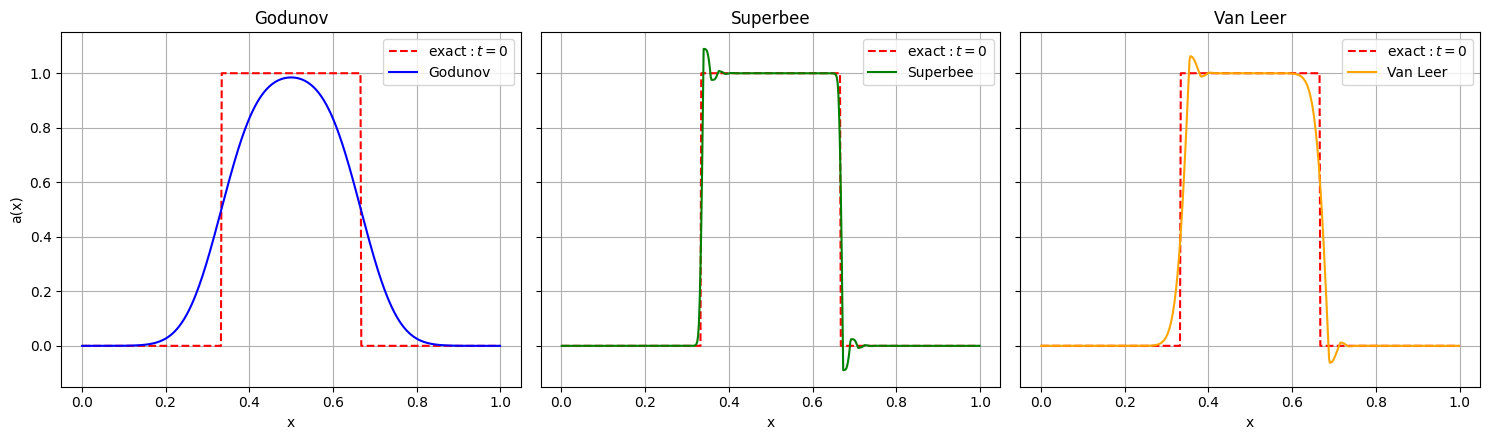

In [5]:
# Plot the results
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
# Setting firts panel
axes[0].plot(x[ilo:ihi+1], solver_godunov.solinit[ilo:ihi+1], '--', lw=1.5, color = 'red', label=r'${\rm exact}: t=0$')
axes[0].plot(x[ilo:ihi+1], solver_godunov.sol[ilo:ihi+1], color='blue', lw=1.5, label='Godunov')
axes[0].set_title('Godunov', fontsize=12)
axes[0].set_xlabel('x')
axes[0].set_ylabel('a(x)') 
axes[0].set_xlim()
axes[0].set_ylim(-0.15, 1.15)
axes[0].grid()
axes[0].legend(loc='upper right')
# Setting second panel
axes[1].plot(x[ilo:ihi+1], solver_godunov.solinit[ilo:ihi+1], '--', lw=1.5, color = 'red', label=r'${\rm exact}: t=0$')
axes[1].plot(x[ilo:ihi+1], solver_superbee.sol[ilo:ihi+1], color='green', lw=1.5, label='Superbee')
axes[1].set_title('Superbee', fontsize=12)
axes[1].set_xlabel('x')
axes[1].set_xlim()
axes[1].set_ylim(-0.15, 1.15)
axes[1].grid()
axes[1].legend(loc='upper right')
# Setting third panel
axes[2].plot(x[ilo:ihi+1], solver_godunov.solinit[ilo:ihi+1], '--', lw=1.5, color = 'red', label=r'${\rm exact}: t=0$')
axes[2].plot(x[ilo:ihi+1], solver_vanleer.sol[ilo:ihi+1], color='orange', lw=1.5, label='Van Leer')
axes[2].set_title('Van Leer', fontsize=12)
axes[2].set_xlabel('x')
axes[2].set_xlim()
axes[2].set_ylim(-0.15, 1.15)
axes[2].grid()
axes[2].legend(loc='upper right')
# Show the plot
plt.tight_layout()
plt.show()

**(g)** Create a single, highly legible figure comparing the final spatial profiles of your simulations from (f). The plot should overlay the results of the different slope limiters and the purely Godunov (Upwind) scheme alongside the exact analytical solution. 

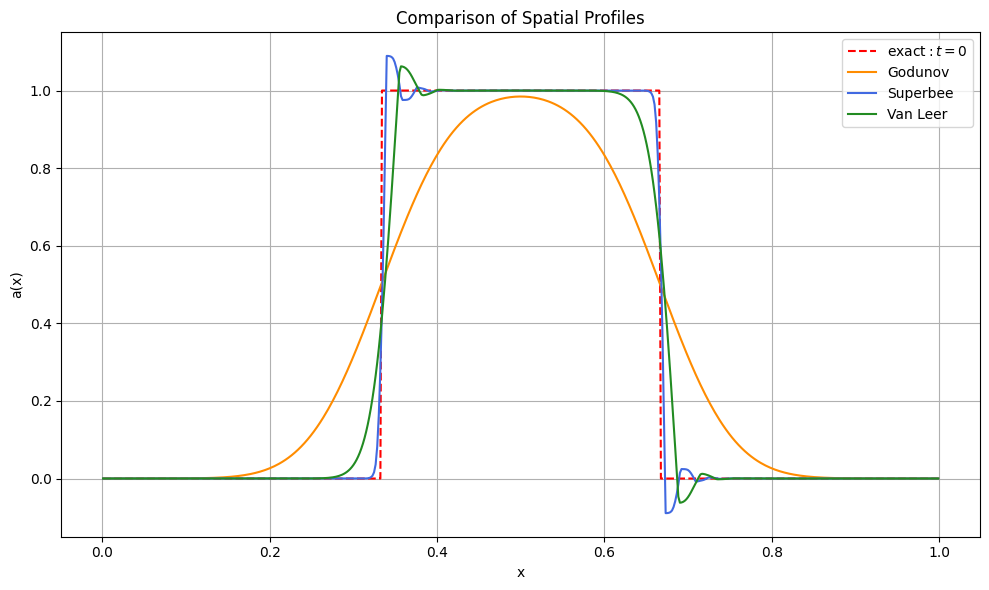

In [6]:
# Plot the results comparing the three methods
plt.figure(figsize=(10, 6))
# Plot the initial condition and the three methods
plt.plot(x[ilo:ihi+1], solver_godunov.solinit[ilo:ihi+1], '--', lw=1.5, color = 'red', label=r'${\rm exact}: t=0$')
plt.plot(x[ilo:ihi+1], solver_godunov.sol[ilo:ihi+1], color='darkorange', linestyle='-', linewidth=1.5, label='Godunov')
plt.plot(x[ilo:ihi+1], solver_superbee.sol[ilo:ihi+1], color='royalblue', linestyle='-', linewidth=1.5, label='Superbee')
plt.plot(x[ilo:ihi+1], solver_vanleer.sol[ilo:ihi+1], color='forestgreen', linestyle='-', linewidth=1.5, label='Van Leer')
# Settings for the plot
plt.title('Comparison of Spatial Profiles')
plt.xlabel('x')
plt.ylabel('a(x)')
plt.xlim()
plt.ylim(-0.15, 1.15)
plt.grid()
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


#### Error Calculation:
**(h)** Write a function to compute the $L_2$ norm error between your numerical solutions and the exact analytical solution at the final time step. Create a bar chart or a formatted table displaying these $L_2$ errors for each numerical scheme used in (f).

In [7]:
def l2_norm_error(ilo, ihi, exact, num):
    '''
    This function helps to compute the L2 norm
    Input:
    - ilo: lowest index
    - ihi: highest index
    - exact: exact solution
    - num: numerical solution
    Output:
    - error: L2 norm of the error
    '''
    # Get number of cells
    num_method = num[ilo:ihi+1]
    exact_method = exact[ilo:ihi+1]
    # Compute the L2 norm of the error
    error = np.sqrt(np.sum((num_method - exact_method)**2) / len(num_method))
    
    return error

In [8]:
# Call the function to compute the errors
error_godunov = l2_norm_error(ilo, ihi, solver_godunov.solinit, solver_godunov.sol)
error_superbee = l2_norm_error(ilo, ihi, solver_godunov.solinit, solver_superbee.sol)
error_vanleer = l2_norm_error(ilo, ihi, solver_godunov.solinit, solver_vanleer.sol)

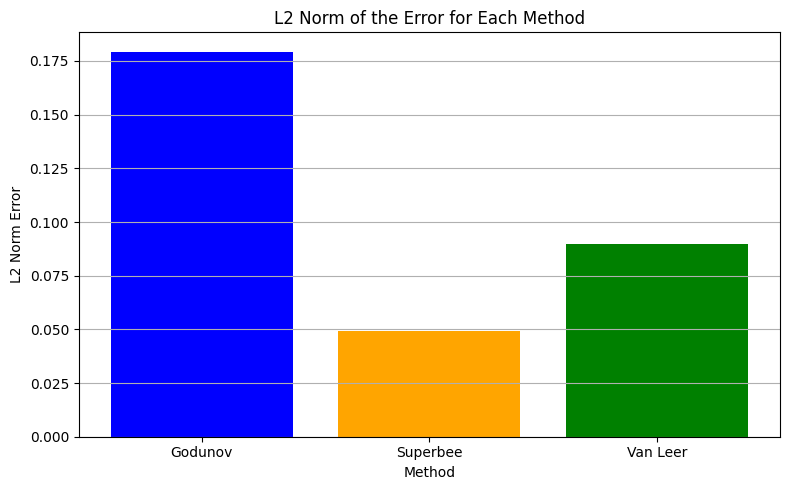

In [9]:
# Settings for the bar chart plot
# Define a list to store the methods
methods = ['Godunov', 'Superbee', 'Van Leer']
# Define a list to store the errors
errors = [error_godunov, error_superbee, error_vanleer]
# Create the bar chart
plt.figure(figsize=(8, 5))
plt.bar(methods, errors, color=['blue', 'orange', 'green'])
plt.title('L2 Norm of the Error for Each Method')
plt.xlabel('Method')
plt.ylabel('L2 Norm Error')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

#### Analysis:

**(i)** Based on your plotted profiles from (g) and your quantitative error analysis from (h), answer the following:

- Which slope limiter provides the most accurate results overall, and why?

In the plots shown in sections g and h, Superbee is the most accurate gradient limiter. This is due to the way it handles different values of r, which reduces potential increases related to gradients.

- How does the Superbee limiter handle the sharp discontinuities of a top-hat profile compared to the Van Leer limiter?

To compare how the two limiters handle discontinuities, we analyze the equation for each of the limiter functions. For the Superbee limiter, the function phi is restricted to being greater in some interval. Similarly, the Van Leer limiter has a different function for phi but is also restricted to being between some interval. The difference is that the Van Leer limiter exhibits asymptotic behavior for r = 2, which limits its ability to handle large values.

- Why does the basic Godunov (Upwind) scheme perform poorly in this specific scenario, and what physical/numerical phenomenon is dominating its solution?

The Godunov scheme is a first-order method, which makes it less accurate than higher-order schemes. From a physical standpoint, the upwind scheme relies on the CFL value to minimize diffusion, which limits the time step to a mesh size of delta x.